# 04 — Fusión de Canales EMG

Este notebook combina la información de 8 canales en una sola variable por feature,
evaluando múltiples estrategias de fusión y el efecto de la normalización por sujeto.

**Pipeline:**
1. Carga de datos transformados (Box-Cox)
2. Normalización Z-score por sujeto
3. η² baseline (canales individuales)
4. Funciones de fusión (6 métodos)
5. η² con fusión — sin normalización por sujeto
6. η² con fusión — con normalización por sujeto
7. Tabla resumen y selección del mejor método por feature
8. Construcción del dataset fused
9. Verificación final

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.patches import Patch

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

FEATURES = ['VAR_STD', 'Range', 'Energy', 'Peak_to_Peak', 'VAR', 'Max', 'MNF', 'SSC']
N_CHANNELS = 8

## 1. Carga de datos

In [46]:
ruta='./data/processed/df_mean.xlsx'

In [48]:
ruta='../data/master/intact_mean_boxcox.csv'

In [49]:
df = pd.read_csv(ruta)

meta_cols = ['origin_db', 'subject', 'stimulus']
signal_cols = [f'Channel {ch}_{feat}' for ch in range(1, N_CHANNELS + 1) for feat in FEATURES]

print(f'Shape: {df.shape}')
print(f'Sujetos: {df["subject"].nunique()}')
print(f'Estímulos: {sorted(df["stimulus"].unique())}')
print(f'Columnas de señal: {len(signal_cols)}')
df.head()

Shape: (609, 67)
Sujetos: 40
Estímulos: [np.int64(22), np.int64(25), np.int64(27), np.int64(30), np.int64(31), np.int64(37), np.int64(40)]
Columnas de señal: 64


,origin_db,subject,stimulus,Channel 1_VAR_STD,Channel 2_VAR_STD,Channel 3_VAR_STD,Channel 4_VAR_STD,Channel 5_VAR_STD,Channel 6_VAR_STD,Channel 7_VAR_STD,...,Channel 7_MNF,Channel 8_MNF,Channel 1_SSC,Channel 2_SSC,Channel 3_SSC,Channel 4_SSC,Channel 5_SSC,Channel 6_SSC,Channel 7_SSC,Channel 8_SSC
0,NinaProDB1,1,22,-0.499909,0.582856,0.577807,-1.553525,-4.477213,-3.066001,0.572112,...,14.244670,12.727570,12.443842,10.682505,11.607175,7.444395,7.810998,8.012637,10.551073,12.524078
1,NinaProDB1,1,25,-0.313655,-0.497703,0.010796,-1.153274,-4.338291,-3.770435,1.647257,...,13.943402,12.368362,11.863911,9.518381,10.405766,9.015483,6.987917,6.807130,10.887068,13.138894
2,NinaProDB1,1,27,0.681886,-0.065447,0.363434,-2.441041,-4.456810,-2.123139,0.888326,...,14.094431,12.093901,13.790913,11.547885,10.743884,7.552270,7.626128,8.008919,10.918947,13.179688
3,NinaProDB1,1,30,1.668193,1.752960,1.343850,-0.669203,-3.460736,-3.435173,1.489593,...,13.758939,12.395379,13.369270,10.635662,10.318345,7.004968,8.311070,8.143636,11.083814,13.078698
4,NinaProDB1,1,31,-3.075228,-1.347938,0.142977,-3.740609,-3.745474,-5.656207,-1.330548,...,12.921324,12.222089,11.245060,8.783536,10.068529,5.545994,8.726164,6.516700,10.644550,13.402996


## 2. Normalización Z-score por sujeto

In [26]:
def normalize_by_subject(df, signal_cols):
    """
    Aplica Z-score (StandardScaler) por cada sujeto sobre las columnas de señal.
    Elimina diferencias de amplitud inter-sujeto.
    """
    df_norm = df.copy()
    for subj, db in df_norm.groupby(['subject', 'origin_db']).groups.keys():
        mask = (df_norm['subject'] == subj) & (df_norm['origin_db'] == db)
        sub_data = df_norm.loc[mask, signal_cols].values.astype(float)
        
        # Si el sujeto tiene 1 sola fila, no se puede standardizar
        if sub_data.shape[0] < 2:
            df_norm.loc[mask, signal_cols] = 0.0
            continue
        
        # Si alguna feature tiene std=0, reemplazar por 0
        stds = np.nanstd(sub_data, axis=0, ddof=1)
        stds[stds == 0] = 1.0  # evitar división por cero
        means = np.nanmean(sub_data, axis=0)
        df_norm.loc[mask, signal_cols] = (sub_data - means) / stds
    
    return df_norm


df_norm = normalize_by_subject(df, signal_cols)
print('Normalización por sujeto completada.')
print(f'Shape original: {df.shape}, Shape normalizado: {df_norm.shape}')

Normalización por sujeto completada.
Shape original: (609, 67), Shape normalizado: (609, 67)


### Verificación: distribuciones antes/después

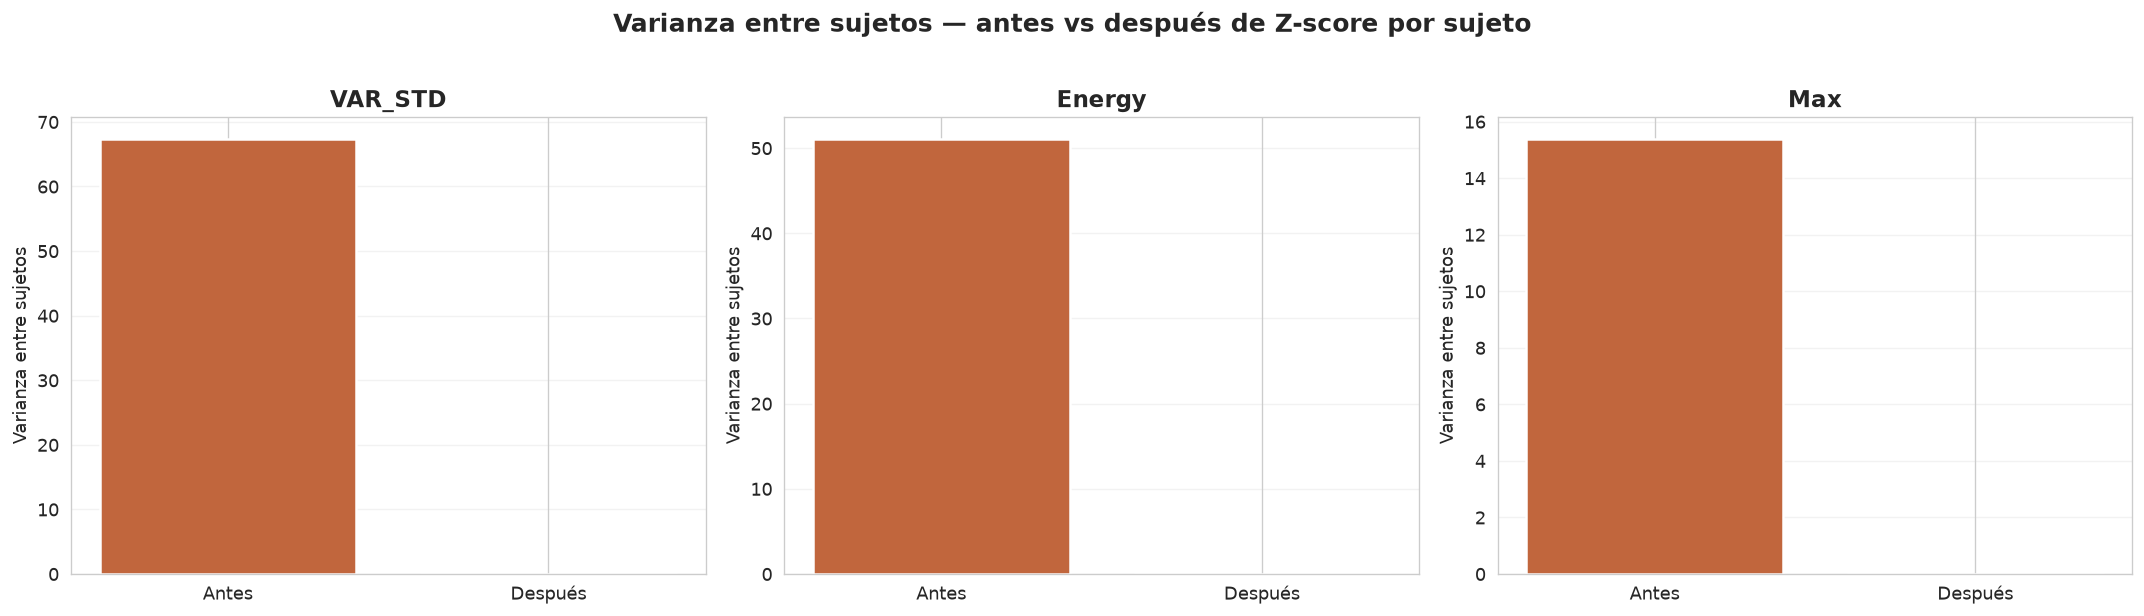

In [27]:
# Verificar que la normalización funciona: comparar varianza por feature entre sujetos
# Antes de normalizar: varianza alta entre sujetos (diferentes escalas)
# Después de normalizar: varianza similar entre sujetos

check_features = ['VAR_STD', 'Energy', 'Max']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(check_features):
    cols = [f'Channel {ch}_{feat}' for ch in range(1, N_CHANNELS + 1)]
    
    # Varianza entre sujetos para cada feature (promedio de los 8 canales)
    var_before = df.groupby('subject')[cols].mean().var()
    var_after = df_norm.groupby('subject')[cols].mean().var()
    
    axes[i].bar(['Antes', 'Después'], [var_before.mean(), var_after.mean()],
                color=['#c1663d', '#3d5a99'], edgecolor='white', linewidth=1.5)
    axes[i].set_title(feat, fontweight='bold', fontsize=14)
    axes[i].set_ylabel('Varianza entre sujetos')
    axes[i].grid(axis='y', alpha=0.25)

fig.suptitle('Varianza entre sujetos — antes vs después de Z-score por sujeto',
             fontweight='bold', fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

## 3. η² baseline — canales individuales (sin fusión, sin normalización)

Calculamos η² para cada canal individual con los datos **sin normalizar**.
Este es el baseline: cuánta separabilidad hay por canal antes de cualquier fusión.

In [28]:
def separability_eta2(groups):
    """
    Calcula eta² (η²) = SS_between / SS_total.
    groups: lista de arrays, uno por clase/estímulo.
    """
    groups = [g[np.isfinite(g)] for g in groups]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) < 2:
        return np.nan
    all_data = np.concatenate(groups)
    if all_data.size == 0:
        return np.nan
    gm = all_data.mean()
    ss_between = sum(len(g) * (g.mean() - gm) ** 2 for g in groups)
    ss_total = ((all_data - gm) ** 2).sum()
    return ss_between / ss_total if ss_total > 0 else np.nan


def compute_eta2_per_channel(df, features, n_channels=8, stimulus_col='stimulus'):
    """
    Calcula η² para cada canal individual de cada feature.
    """
    rows = []
    for feat in features:
        for ch in range(1, n_channels + 1):
            col = f'Channel {ch}_{feat}'
            if col not in df.columns:
                continue
            groups = [x[col].dropna().values for _, x in df.groupby(stimulus_col)]
            eta2 = separability_eta2(groups)
            rows.append({'feature': feat, 'channel': ch, 'eta2': eta2})
    return pd.DataFrame(rows)


# Baseline: sin normalización por sujeto
eta2_baseline = compute_eta2_per_channel(df, FEATURES)
print('η² baseline (canales individuales, sin normalización por sujeto):')
eta2_baseline.pivot(index='feature', columns='channel', values='eta2').round(4)

η² baseline (canales individuales, sin normalización por sujeto):


channel,1,2,3,4,5,6,7,8
feature,,,,,,,,
Energy,0.0019,0.0045,0.0027,0.0013,0.0016,0.0021,0.0021,0.0018
MNF,0.0002,0.0004,0.0006,0.0003,0.0006,0.0006,0.0005,0.0001
Max,0.0016,0.0033,0.0023,0.0011,0.0013,0.0016,0.0017,0.0016
Peak_to_Peak,0.0020,0.0050,0.0035,0.0015,0.0016,0.0017,0.0017,0.0017
Range,0.0015,0.0063,0.0035,0.0020,0.0025,0.0033,0.0029,0.0016
SSC,0.0001,0.0001,0.0003,0.0002,0.0002,0.0004,0.0006,0.0001
VAR,0.0015,0.0059,0.0033,0.0016,0.0020,0.0031,0.0028,0.0016
VAR_STD,0.0015,0.0039,0.0026,0.0009,0.0012,0.0018,0.0017,0.0014


In [29]:
# η² baseline: canales individuales, CON normalización por sujeto
eta2_baseline_norm = compute_eta2_per_channel(df_norm, FEATURES)
print('η² baseline (canales individuales, CON normalización por sujeto):')
eta2_baseline_norm.pivot(index='feature', columns='channel', values='eta2').round(4)

η² baseline (canales individuales, CON normalización por sujeto):


channel,1,2,3,4,5,6,7,8
feature,,,,,,,,
Energy,0.3104,0.4602,0.3269,0.1711,0.2255,0.3140,0.3295,0.3449
MNF,0.0840,0.1552,0.2013,0.0878,0.1379,0.1068,0.0734,0.0491
Max,0.3366,0.4755,0.3638,0.1878,0.2415,0.3174,0.3426,0.3650
Peak_to_Peak,0.3228,0.4713,0.3795,0.1301,0.2385,0.3496,0.3674,0.3555
Range,0.2065,0.4831,0.2925,0.1540,0.2050,0.3139,0.2937,0.2609
SSC,0.0203,0.0459,0.0481,0.0565,0.0699,0.0406,0.0295,0.0381
VAR,0.1852,0.4578,0.2748,0.1306,0.1673,0.3019,0.2852,0.2431
VAR_STD,0.3033,0.4514,0.3267,0.1160,0.2021,0.3305,0.3317,0.3325


## 4. Funciones de fusión

In [30]:
def fuse_channels(df, feature, method, n_channels=8):
    """
    Fusiona los 8 canales de una feature en una sola variable.
    
    Parámetros:
        df     : DataFrame con las columnas Channel {1-8}_{feature}
        feature: nombre de la feature (ej. 'VAR_STD')
        method : str — 'mean', 'median', 'pca', 'wmean', 'max', 'std'
    """
    cols = [f'Channel {ch}_{feature}' for ch in range(1, n_channels + 1)]
    cols = [c for c in cols if c in df.columns]
    X = df[cols].values.astype(float)
    
    if method == 'mean':
        return np.nanmean(X, axis=1)
    elif method == 'median':
        return np.nanmedian(X, axis=1)
    elif method == 'pca':
        # PCA: primera componente principal
        X_clean = np.nan_to_num(X, nan=0.0)
        if X_clean.shape[0] < 2:
            return np.nanmean(X, axis=1)
        pca = PCA(n_components=1)
        return pca.fit_transform(X_clean).ravel()
    elif method == 'wmean':
        # Media ponderada: peso = 1 / varianza del canal
        vars_ = np.nanvar(X, axis=0)
        vars_[vars_ == 0] = 1e-10  # evitar división por cero
        weights = 1.0 / vars_
        weights = weights / weights.sum()  # normalizar pesos
        return np.nansum(X * weights, axis=1)
    elif method == 'max':
        return np.nanmax(X, axis=1)
    elif method == 'std':
        return np.nanstd(X, axis=1)
    else:
        raise ValueError(f'Método desconocido: {method}')


def fuse_all_features(df, features, method, n_channels=8):
    """
    Fusiona todas las features de un DataFrame usando un método dado.
    Devuelve un DataFrame con las columnas fused.
    """
    result = df[['origin_db', 'subject', 'stimulus']].copy()
    for feat in features:
        result[f'Fused_{feat}'] = fuse_channels(df, feat, method, n_channels)
    return result


print('Funciones de fusión definidas: mean, median, pca, wmean, max, std')

Funciones de fusión definidas: mean, median, pca, wmean, max, std


## 5. η² con fusión — sin normalización por sujeto

In [31]:
def compute_eta2_fusion(df, features, methods, n_channels=8, stimulus_col='stimulus'):
    """
    Calcula η² para cada feature × cada método de fusión.
    """
    rows = []
    for feat in features:
        for method in methods:
            fused = fuse_channels(df, feat, method, n_channels)
            groups = [fused[df[stimulus_col] == s] for s in sorted(df[stimulus_col].unique())]
            groups = [g[np.isfinite(g)] for g in groups]
            eta2 = separability_eta2(groups)
            rows.append({'feature': feat, 'method': method, 'eta2': eta2})
    return pd.DataFrame(rows)


METHODS = ['mean', 'median', 'pca', 'wmean', 'max', 'std']

# Sin normalización por sujeto
eta2_fusion_raw = compute_eta2_fusion(df, FEATURES, METHODS)
print('η² con fusión — SIN normalización por sujeto:')
eta2_fusion_raw.pivot(index='feature', columns='method', values='eta2').round(4)

η² con fusión — SIN normalización por sujeto:


method,max,mean,median,pca,std,wmean
feature,,,,,,
Energy,0.0018,0.0018,0.0026,0.0018,0.0133,0.0018
MNF,0.0005,0.0003,0.0003,0.0003,0.0008,0.0003
Max,0.0015,0.0015,0.0022,0.0015,0.0143,0.0015
Peak_to_Peak,0.0017,0.0018,0.0028,0.0018,0.0146,0.0018
Range,0.0013,0.0024,0.0032,0.0024,0.0170,0.0024
SSC,0.0001,0.0002,0.0002,0.0002,0.0009,0.0002
VAR,0.0013,0.0022,0.0029,0.0022,0.0128,0.0022
VAR_STD,0.0012,0.0014,0.0023,0.0014,0.0118,0.0014


## 6. η² con fusión — CON normalización por sujeto

In [32]:
# Con normalización por sujeto
eta2_fusion_norm = compute_eta2_fusion(df_norm, FEATURES, METHODS)
print('η² con fusión — CON normalización por sujeto:')
eta2_fusion_norm.pivot(index='feature', columns='method', values='eta2').round(4)

η² con fusión — CON normalización por sujeto:


method,max,mean,median,pca,std,wmean
feature,,,,,,
Energy,0.4064,0.4874,0.4580,0.4870,0.0728,0.4874
MNF,0.1408,0.1811,0.1784,0.1854,0.2126,0.1811
Max,0.4266,0.5110,0.4826,0.5110,0.0833,0.5110
Peak_to_Peak,0.4352,0.5338,0.5169,0.5411,0.0998,0.5338
Range,0.3683,0.4423,0.4196,0.4455,0.0986,0.4423
SSC,0.0405,0.0620,0.0570,0.0650,0.1763,0.0620
VAR,0.3378,0.4252,0.4111,0.4310,0.0922,0.4252
VAR_STD,0.4029,0.4954,0.4834,0.5012,0.0856,0.4954


## 7. Tabla resumen y selección del mejor método

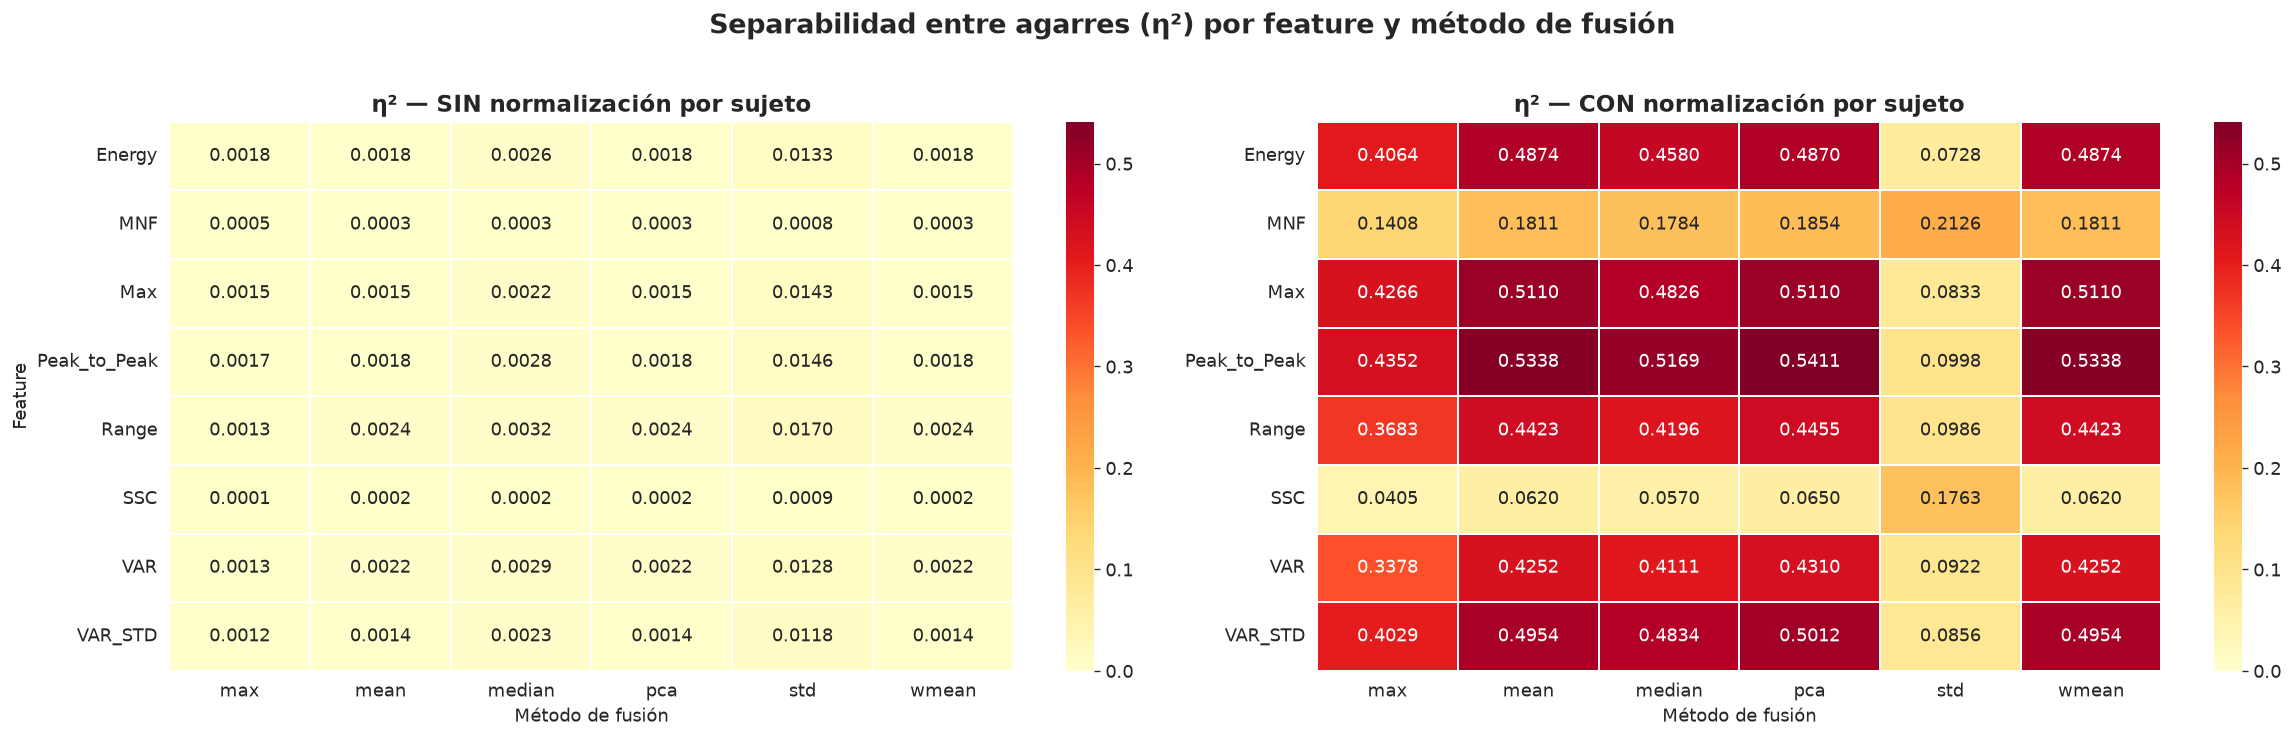

In [33]:
# Heatmap comparativo: η² por feature × método (con normalización por sujeto)
pivot_norm = eta2_fusion_norm.pivot(index='feature', columns='method', values='eta2')

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Heatmap sin normalización
pivot_raw = eta2_fusion_raw.pivot(index='feature', columns='method', values='eta2')
sns.heatmap(pivot_raw, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[0],
            linewidths=1, linecolor='white', vmin=0, vmax=max(pivot_raw.max().max(), pivot_norm.max().max()))
axes[0].set_title('η² — SIN normalización por sujeto', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Método de fusión')
axes[0].set_ylabel('Feature')

# Heatmap con normalización
sns.heatmap(pivot_norm, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[1],
            linewidths=1, linecolor='white', vmin=0, vmax=max(pivot_raw.max().max(), pivot_norm.max().max()))
axes[1].set_title('η² — CON normalización por sujeto', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Método de fusión')
axes[1].set_ylabel('')

fig.suptitle('Separabilidad entre agarres (η²) por feature y método de fusión',
             fontweight='bold', fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

In [34]:
# Tabla resumen: mejor método por feature (con normalización por sujeto)
best_methods = eta2_fusion_norm.loc[
    eta2_fusion_norm.groupby('feature')['eta2'].idxmax()
][['feature', 'method', 'eta2']].reset_index(drop=True)
best_methods.columns = ['Feature', 'Mejor_método', 'η²']

# Agregar η² del baseline (mejor canal individual)
best_baseline = eta2_baseline_norm.groupby('feature')['eta2'].max().reset_index()
best_baseline.columns = ['Feature', 'η²_baseline']

summary = best_methods.merge(best_baseline, on='Feature')
summary['Mejora_%'] = ((summary['η²'] - summary['η²_baseline']) / summary['η²_baseline'] * 100)
summary = summary.round(4)

print('Tabla resumen — Mejor método por feature (con normalización por sujeto):')
print(summary.to_string(index=False))

Tabla resumen — Mejor método por feature (con normalización por sujeto):
     Feature Mejor_método     η²  η²_baseline  Mejora_%
      Energy         mean 0.4874       0.4602    5.9136
         MNF          std 0.2126       0.2013    5.5992
         Max         mean 0.5110       0.4755    7.4762
Peak_to_Peak          pca 0.5411       0.4713   14.8135
       Range          pca 0.4455       0.4831   -7.7858
         SSC          std 0.1763       0.0699  152.0904
         VAR          pca 0.4310       0.4578   -5.8510
     VAR_STD          pca 0.5012       0.4514   11.0430


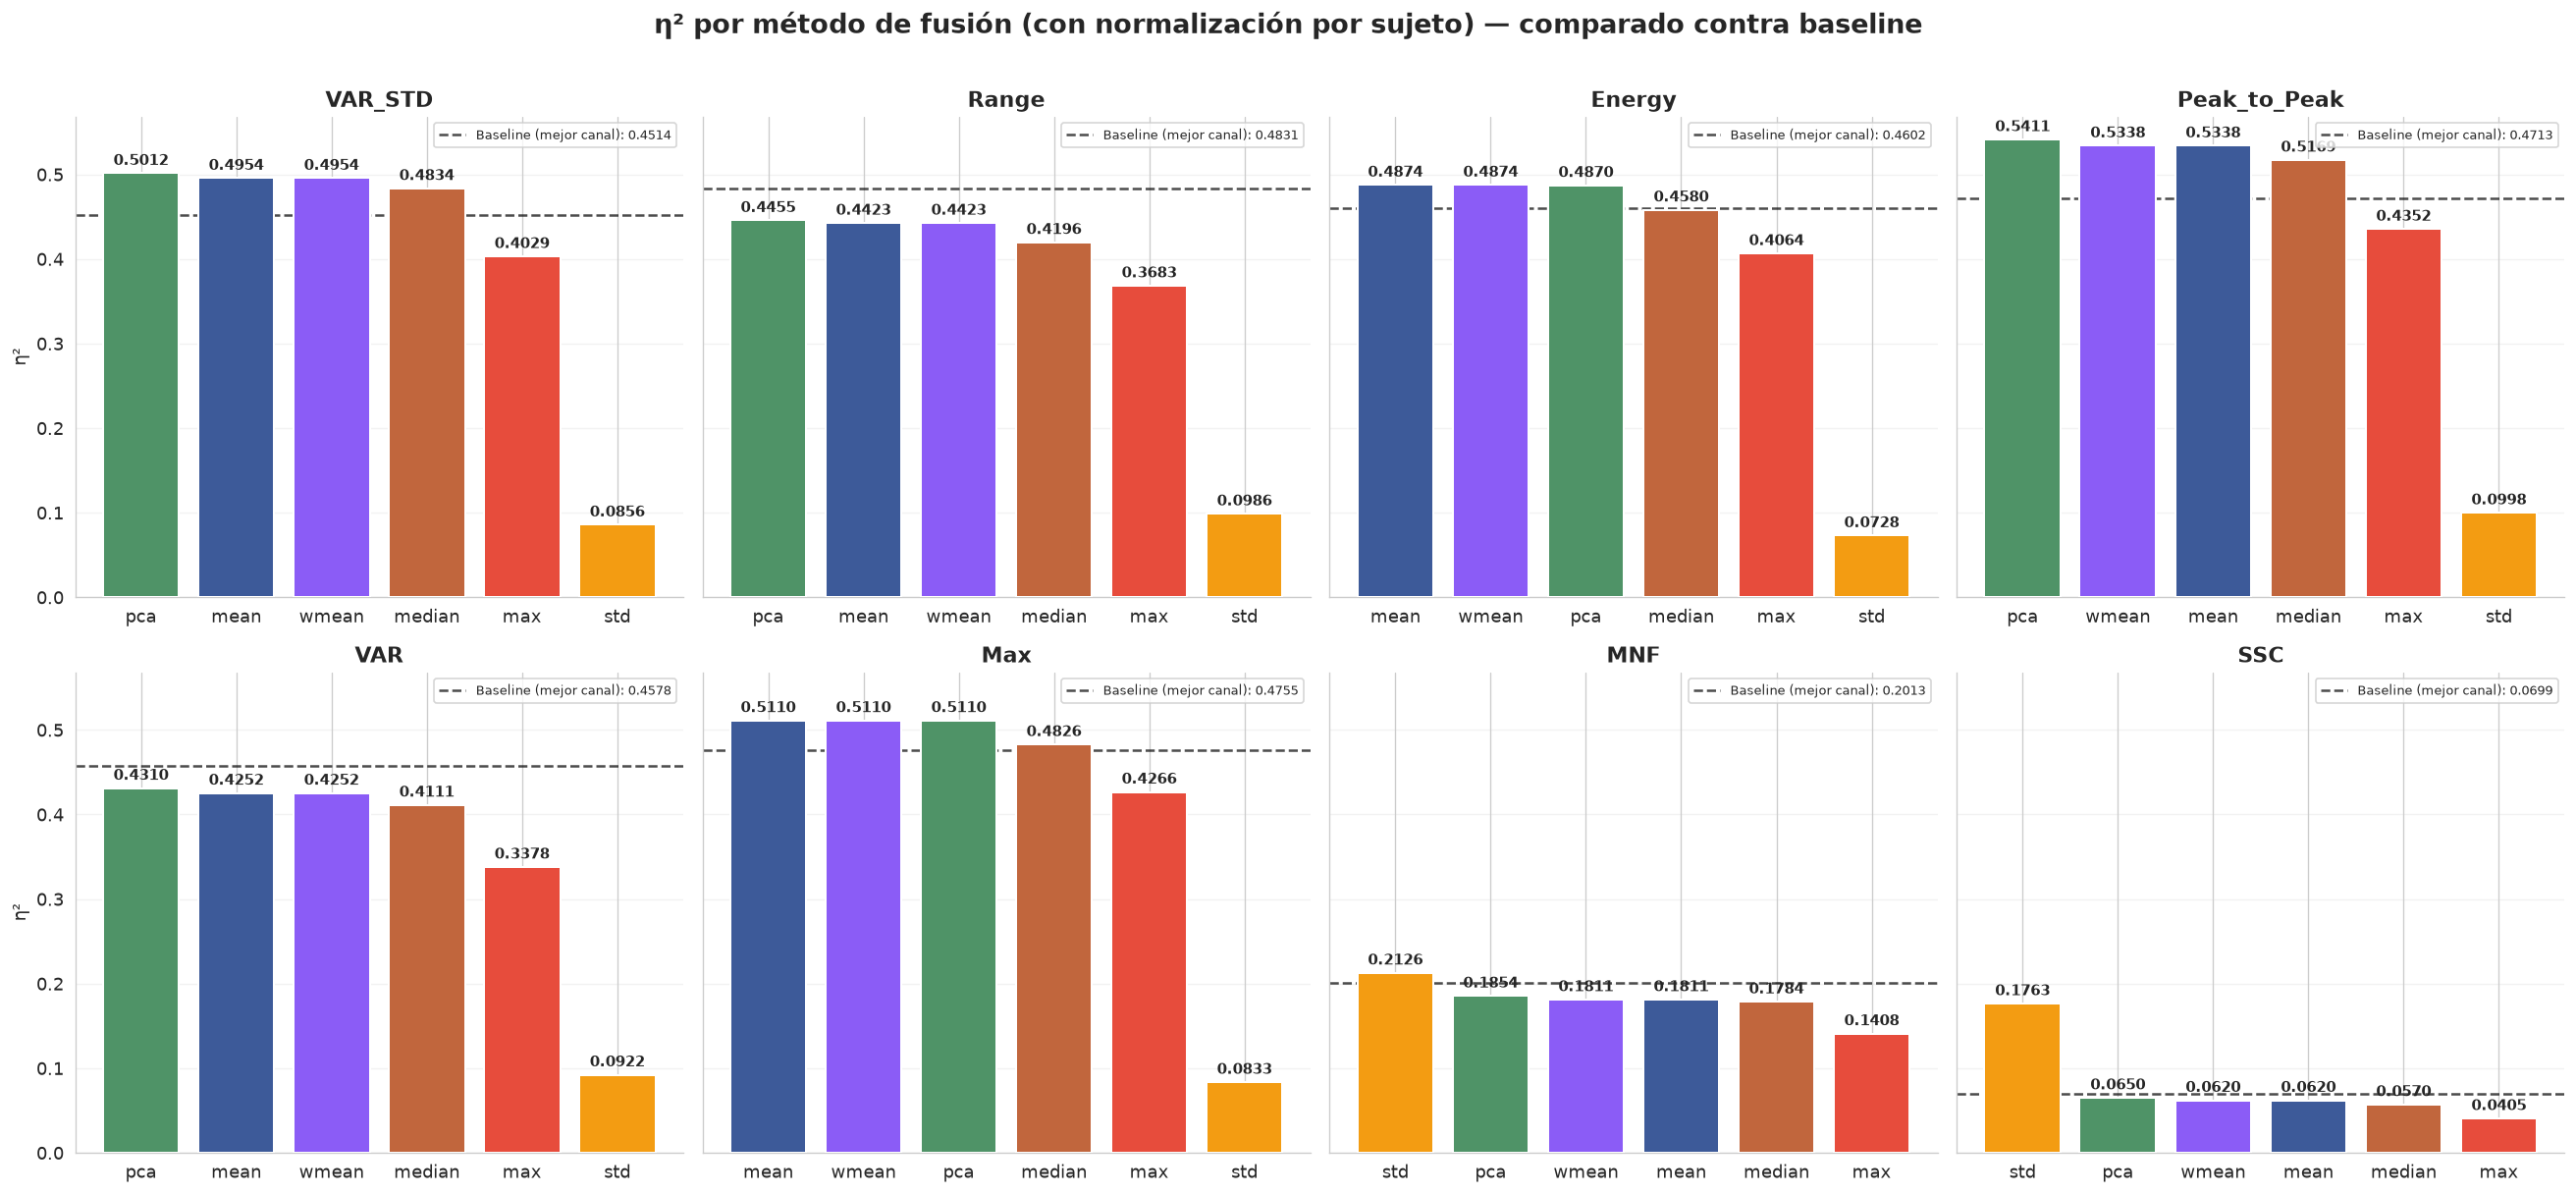

In [35]:
# Barras agrupadas: comparación de los 6 métodos por feature
fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharey=True)
axes = axes.flatten()

colors = {'mean': '#3d5a99', 'median': '#c1663d', 'pca': '#4f9367',
          'wmean': '#8b5cf6', 'max': '#e74c3c', 'std': '#f39c12'}

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    sub = eta2_fusion_norm[eta2_fusion_norm['feature'] == feat].copy()
    sub = sub.sort_values('eta2', ascending=False)
    
    bars = ax.bar(sub['method'], sub['eta2'], color=[colors[m] for m in sub['method']],
                  edgecolor='white', linewidth=1.2, zorder=3)
    ax.bar_label(bars, fmt='%.4f', fontsize=9, fontweight='bold', padding=3)
    
    # Línea del baseline (mejor canal individual)
    bl = eta2_baseline_norm[eta2_baseline_norm['feature'] == feat]['eta2'].max()
    ax.axhline(bl, color='black', ls='--', lw=1.5, alpha=0.7, label=f'Baseline (mejor canal): {bl:.4f}')
    
    ax.set_title(feat, fontweight='bold', fontsize=13)
    ax.set_ylabel('η²' if i % 4 == 0 else '')
    ax.grid(axis='y', alpha=0.25, zorder=0)
    ax.legend(fontsize=8, loc='upper right')
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

fig.suptitle('η² por método de fusión (con normalización por sujeto) — comparado contra baseline',
             fontweight='bold', fontsize=16, y=1.01)
fig.tight_layout()
plt.show()

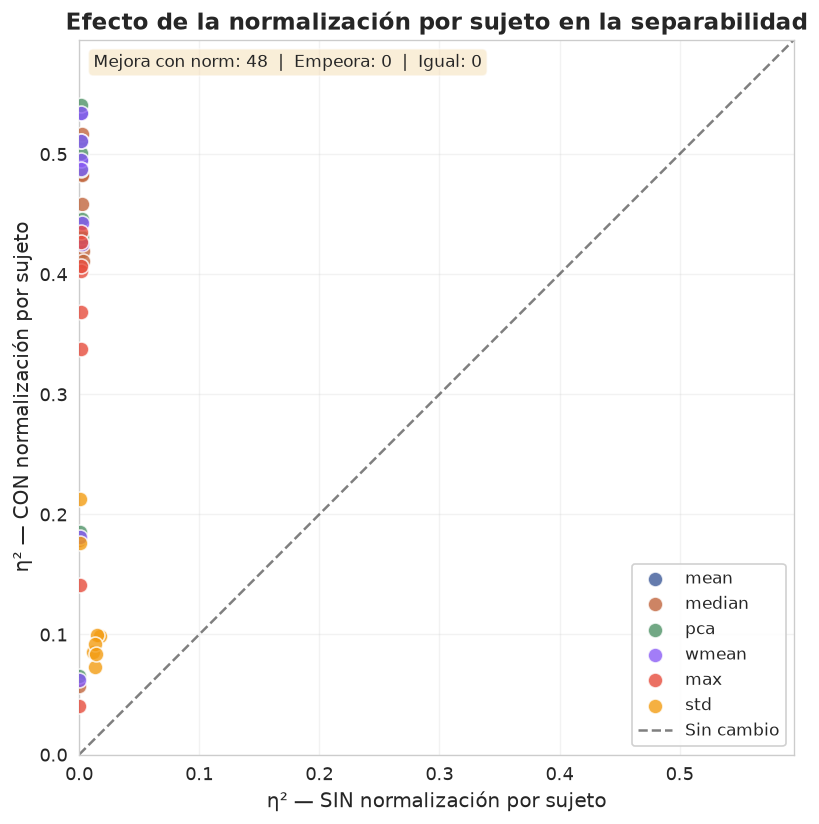

In [36]:
# Efecto de la normalización por sujeto: scatter η²(sin norm) vs η²(con norm)
merged = eta2_fusion_raw.merge(
    eta2_fusion_norm, on=['feature', 'method'], suffixes=('_raw', '_norm')
)

fig, ax = plt.subplots(figsize=(8, 7))

for method in METHODS:
    sub = merged[merged['method'] == method]
    ax.scatter(sub['eta2_raw'], sub['eta2_norm'], s=80, alpha=0.8,
               label=method, color=colors[method], edgecolor='white', zorder=3)

lim = (0, max(merged[['eta2_raw', 'eta2_norm']].max().max() * 1.1, 0.01))
ax.plot(lim, lim, 'k--', lw=1.5, alpha=0.5, label='Sin cambio')
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect('equal')
ax.set_xlabel('η² — SIN normalización por sujeto', fontsize=12)
ax.set_ylabel('η² — CON normalización por sujeto', fontsize=12)
ax.set_title('Efecto de la normalización por sujeto en la separabilidad',
             fontweight='bold', fontsize=14)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(alpha=0.25)

# Anotar cuántos puntos están por encima/debajo de la diagonal
above = (merged['eta2_norm'] > merged['eta2_raw']).sum()
below = (merged['eta2_norm'] < merged['eta2_raw']).sum()
equal = (merged['eta2_norm'] == merged['eta2_raw']).sum()
ax.text(0.02, 0.98, f'Mejora con norm: {above}  |  Empeora: {below}  |  Igual: {equal}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 8. Construcción del dataset fused

In [37]:
# Construir el dataset fused usando el mejor método por feature sobre datos normalizados
best_method_dict = dict(zip(summary['Feature'], summary['Mejor_método']))
print('Mejores métodos por feature:')
for feat, method in best_method_dict.items():
    print(f'  {feat}: {method}')

# Aplicar fusión
df_fused = df_norm[['origin_db', 'subject', 'stimulus']].copy()
for feat in FEATURES:
    method = best_method_dict[feat]
    df_fused[f'Fused_{feat}'] = fuse_channels(df_norm, feat, method)

print(f'\nShape del dataset fused: {df_fused.shape}')
df_fused.head()

Mejores métodos por feature:
  Energy: mean
  MNF: std
  Max: mean
  Peak_to_Peak: pca
  Range: pca
  SSC: std
  VAR: pca
  VAR_STD: pca

Shape del dataset fused: (609, 11)


,origin_db,subject,stimulus,Fused_VAR_STD,Fused_Range,Fused_Energy,Fused_Peak_to_Peak,Fused_VAR,Fused_Max,Fused_MNF,Fused_SSC
0,NinaProDB1,1,22,-0.225013,-0.024862,-0.310517,-0.010566,-0.094865,-0.236213,0.656811,0.739104
1,NinaProDB1,1,25,-0.202066,1.369338,0.005157,-0.994448,1.227454,-0.135069,0.866327,0.838178
2,NinaProDB1,1,27,0.241825,0.027601,-0.092090,0.498575,0.013308,-0.091106,0.502952,0.385232
3,NinaProDB1,1,30,2.626186,3.150722,0.788556,2.303209,3.093538,0.737479,0.622190,0.446209
4,NinaProDB1,1,31,-3.301008,-3.281905,-1.322711,-3.217448,-3.118561,-1.313725,0.787552,0.870972


In [38]:
# Guardar
df_fused.to_csv('../data/master/intact_boxcox_fused.csv', index=False)
print('Dataset fused guardado en: data/master/intact_boxcox_fused.csv')

Dataset fused guardado en: data/master/intact_boxcox_fused.csv


## 9. Verificación final

In [39]:
# Verificar η² del dataset fused
fused_cols = [f'Fused_{feat}' for feat in FEATURES]

eta2_fused = []
for feat in FEATURES:
    col = f'Fused_{feat}'
    groups = [x[col].dropna().values for _, x in df_fused.groupby('stimulus')]
    eta2 = separability_eta2(groups)
    eta2_fused.append({'feature': feat, 'η²_fused': eta2})

eta2_fused_df = pd.DataFrame(eta2_fused)

# Comparar con el mejor η² de fusión (de la tabla resumen)
comparison = summary[['Feature', 'η²', 'Mejor_método']].merge(eta2_fused_df, left_on='Feature', right_on='feature')
comparison = comparison[['Feature', 'Mejor_método', 'η²', 'η²_fused']]
comparison.columns = ['Feature', 'Método', 'η² teórico', 'η² verificado']
print('Verificación del dataset fused:')
print(comparison.round(4).to_string(index=False))

Verificación del dataset fused:
     Feature Método  η² teórico  η² verificado
      Energy   mean      0.4874         0.4874
         MNF    std      0.2126         0.2126
         Max   mean      0.5110         0.5110
Peak_to_Peak    pca      0.5411         0.5411
       Range    pca      0.4455         0.4455
         SSC    std      0.1763         0.1763
         VAR    pca      0.4310         0.4310
     VAR_STD    pca      0.5012         0.5012


/tmp/ipykernel_21142/1011751613.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fused, x='stimulus', y=col, ax=ax,


/tmp/ipykernel_21142/1011751613.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fused, x='stimulus', y=col, ax=ax,
/tmp/ipykernel_21142/1011751613.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fused, x='stimulus', y=col, ax=ax,
/tmp/ipykernel_21142/1011751613.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fused, x='stimulus', y=col, ax=ax,
/tmp/ipykernel_21142/1011751613.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable

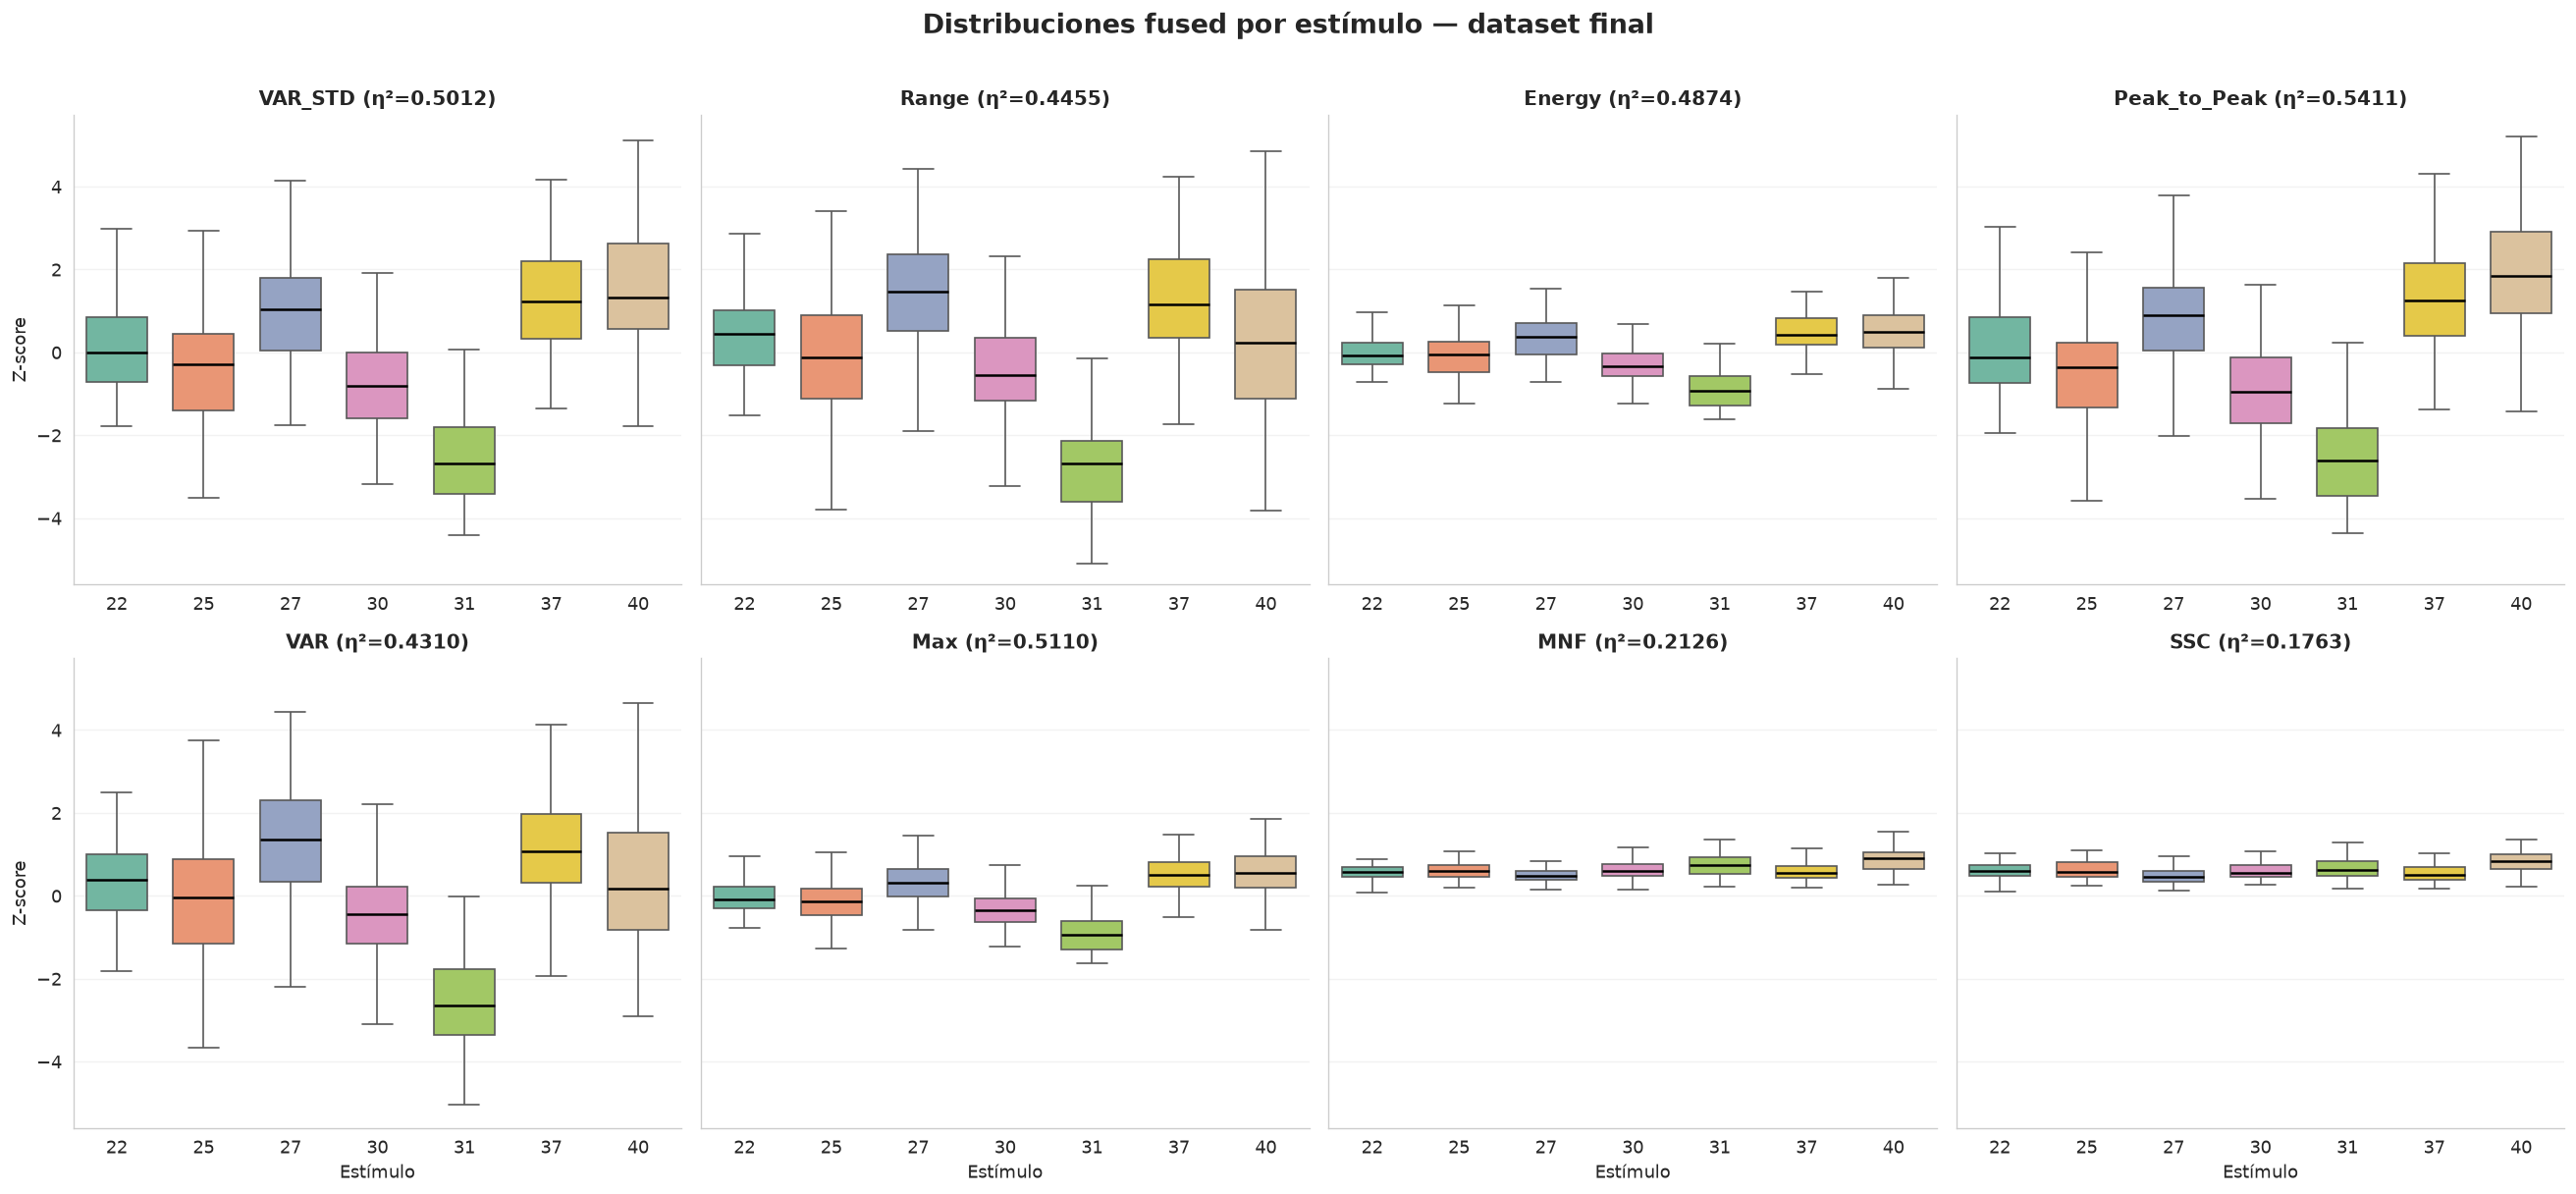

In [40]:
# Distribuciones fused por estimulo (boxplot)
fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharey=True)
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    col = f'Fused_{feat}'
    sns.boxplot(data=df_fused, x='stimulus', y=col, ax=ax,
                palette='Set2', showfliers=False, width=0.7,
                medianprops=dict(color='black', linewidth=1.5))
    ax.set_title(f'{feat} (η²={eta2_fused_df.loc[eta2_fused_df["feature"]==feat, "η²_fused"].values[0]:.4f})',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Estímulo' if i >= 4 else '')
    ax.set_ylabel('Z-score' if i % 4 == 0 else '')
    ax.grid(axis='y', alpha=0.25)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

fig.suptitle('Distribuciones fused por estímulo — dataset final',
             fontweight='bold', fontsize=16, y=1.01)
fig.tight_layout()
plt.show()

In [41]:
# Silhouette score global del dataset fused
from sklearn.metrics import silhouette_score

X_fused = df_fused[fused_cols].values
labels = df_fused['stimulus'].values

# Filtrar NaN
mask = ~np.isnan(X_fused).any(axis=1)
sil = silhouette_score(X_fused[mask], labels[mask])
print(f'Silhouette score del dataset fused: {sil:.4f}')

# Comparar con el dataset original (mejores canales)
best_channel_cols = []
for feat in FEATURES:
    best_ch = eta2_baseline_norm[eta2_baseline_norm['feature'] == feat].sort_values('eta2', ascending=False).iloc[0]['channel']
    best_channel_cols.append(f'Channel {int(best_ch)}_{feat}')

X_best = df_norm[best_channel_cols].values
mask2 = ~np.isnan(X_best).any(axis=1)
sil_baseline = silhouette_score(X_best[mask2], labels[mask2])
print(f'Silhouette score baseline (mejores canales individuales): {sil_baseline:.4f}')

Silhouette score del dataset fused: -0.0768
Silhouette score baseline (mejores canales individuales): -0.0494


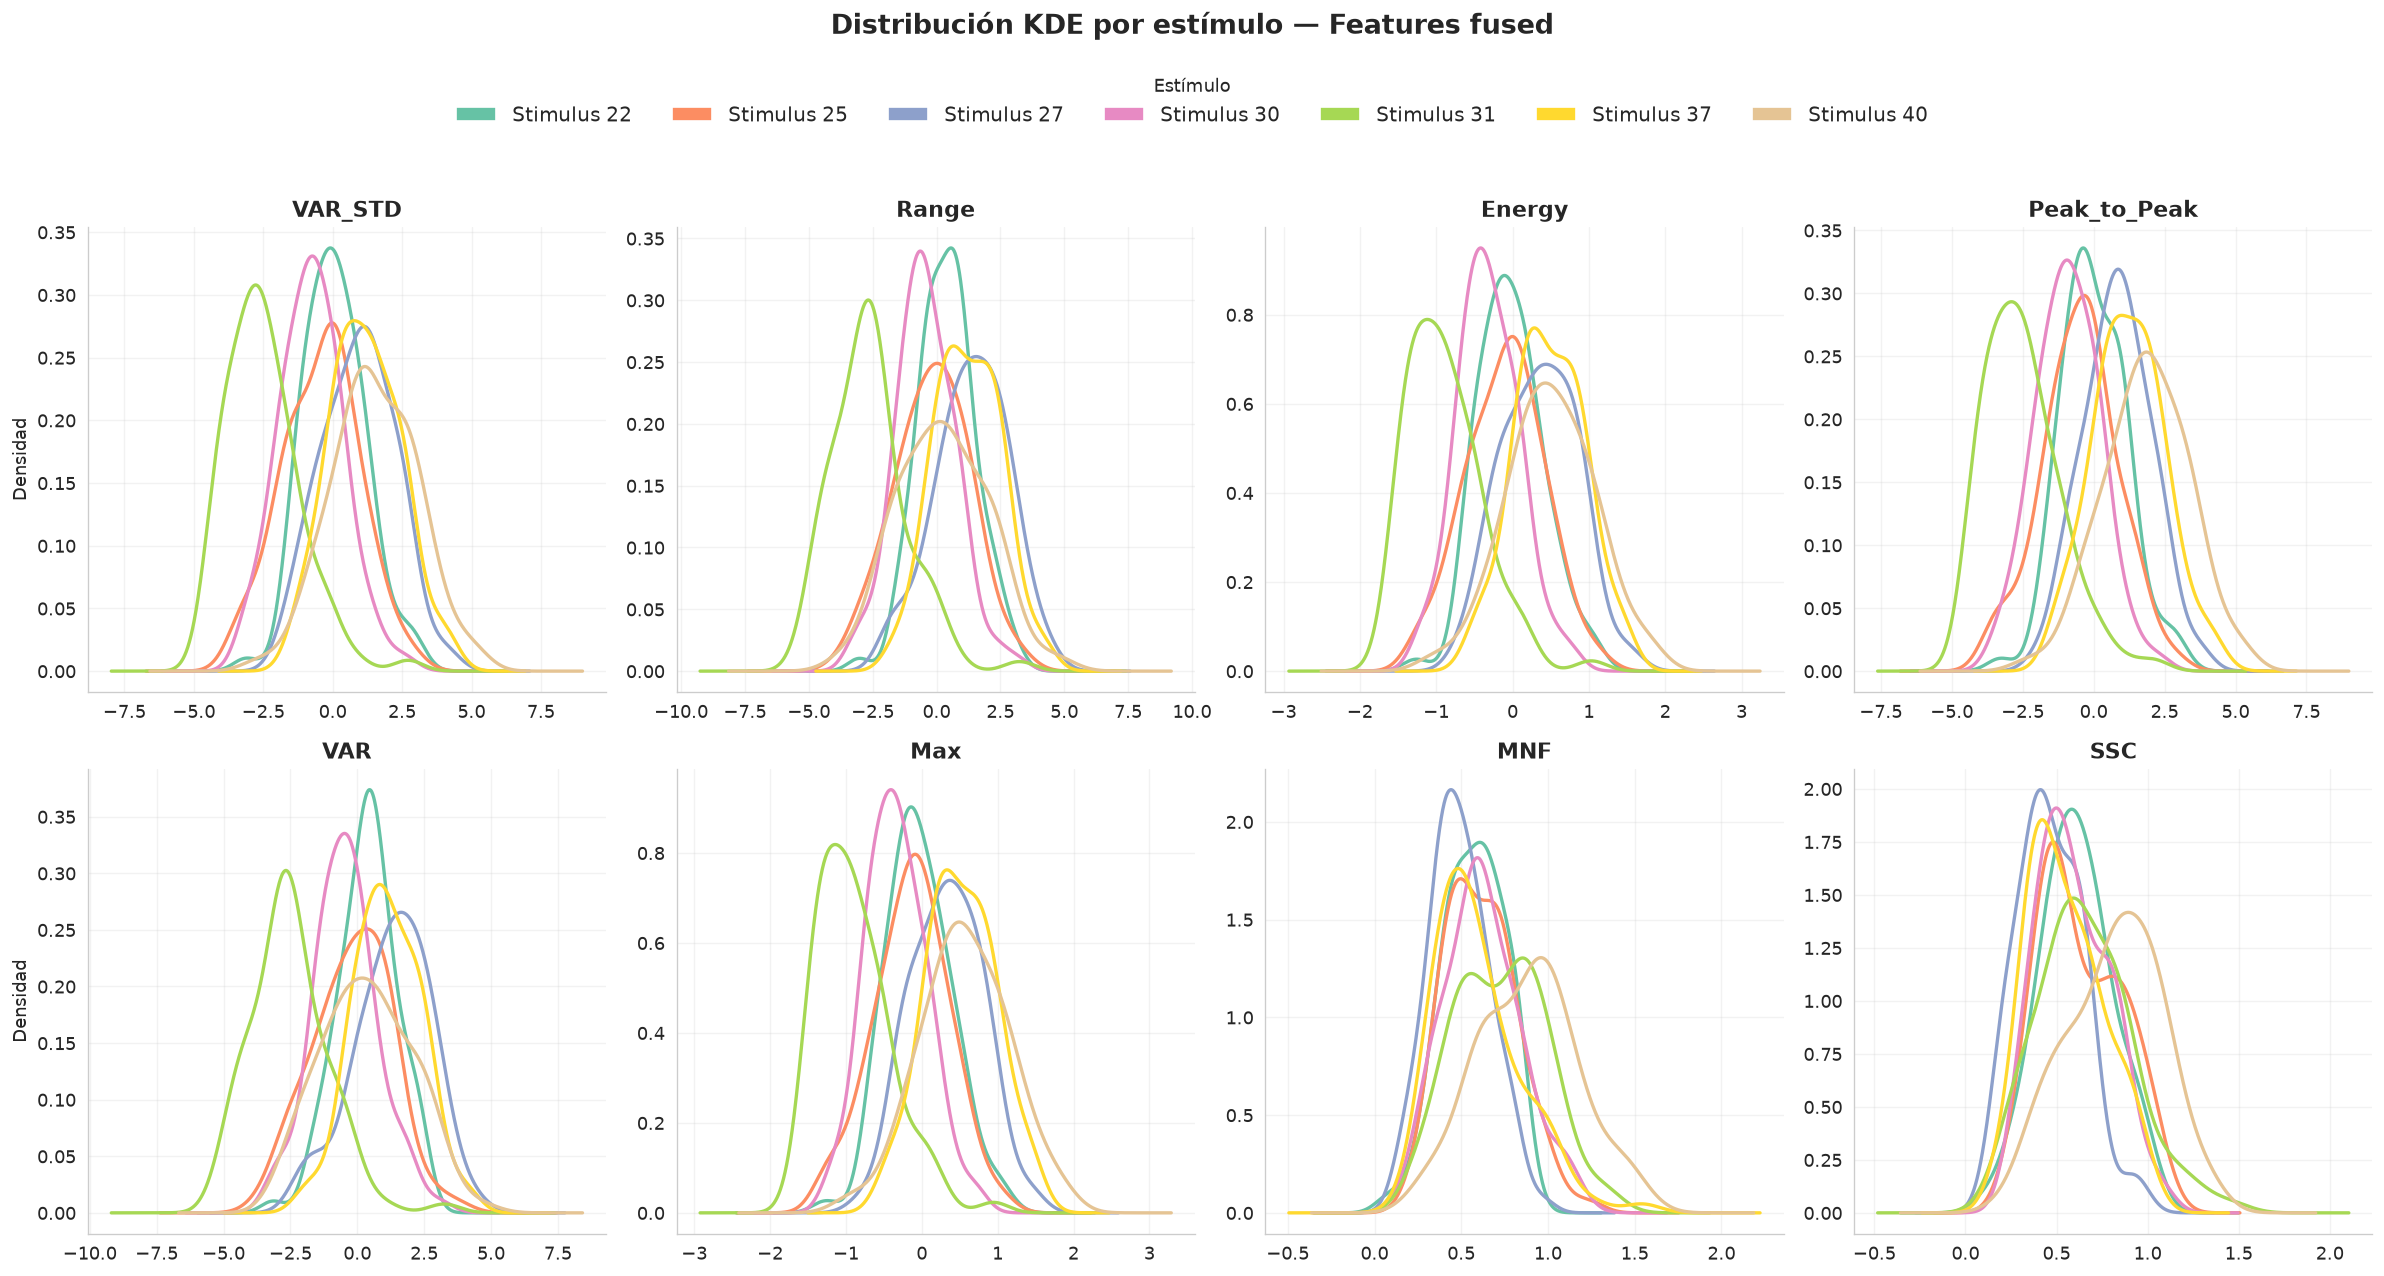

In [42]:
def plot_kde_grid(df, features, stimulus_col='stimulus', 
                  prefix='Fused_', palette='Set2', figsize=(20, 10)):
    """
    Grid 2×4 con KDE de cada feature por estímulo.
    Leyenda compartida centrada arriba de la figura.
    """
    stimuli = sorted(df[stimulus_col].unique())
    colors = sns.color_palette(palette, n_colors=len(stimuli))
    color_map = dict(zip(stimuli, colors))
    
    fig, axes = plt.subplots(2, 4, figsize=figsize)
    axes = axes.flatten()
    
    for i, feat in enumerate(features):
        ax = axes[i]
        col = f'{prefix}{feat}'
        for stim in stimuli:
            subset = df.loc[df[stimulus_col] == stim, col].dropna()
            subset.plot.kde(ax=ax, color=color_map[stim], linewidth=2)
        
        ax.set_title(feat, fontweight='bold', fontsize=13)
        ax.set_xlabel('')
        ax.set_ylabel('Densidad' if i % 4 == 0 else '')
        ax.grid(alpha=0.25)
        ax.set_xlim(ax.get_xlim())  # fijar límites para consistencia
        for s in ('top', 'right'):
            ax.spines[s].set_visible(False)
    
    # Leyenda centrada arriba
    handles = [Patch(facecolor=color_map[s], label=f'Stimulus {s}') for s in stimuli]
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.02),
               ncol=len(stimuli), fontsize=12, frameon=False, title='Estímulo')
    
    fig.suptitle('Distribución KDE por estímulo — Features fused', 
                 fontweight='bold', fontsize=16, y=1.06)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    return fig

plot_kde_grid(df_fused, FEATURES)
plt.show()